In [3]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append(os.path.abspath('..'))
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
import os
from scripts.data_loader import MacroDataLoader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Load data using OOP pipeline
loader = MacroDataLoader('../data/master_data1.csv')
loader.load()
loader.build_lag_features()
X, y = loader.get_feature_matrix()


In [4]:
# Train XGBoost on full dataset for SHAP
from xgboost import XGBRegressor
model_shap = XGBRegressor(learning_rate=0.05, max_depth=3,
                          n_estimators=100, subsample=0.8,
                          random_state=42)
model_shap.fit(X, y)
print("Model trained on full dataset")

Model trained on full dataset


In [5]:
# TreeExplainer designed specifically for XGBoost
explainer = shap.TreeExplainer(model_shap)
shap_values = explainer.shap_values(X)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (160, 6)


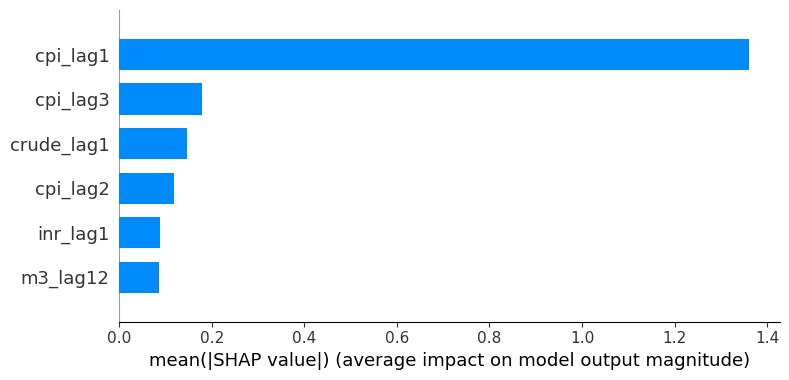

In [6]:
# Global feature importance — which features matter most on average
shap.summary_plot(shap_values, X, plot_type='bar')

## SHAP Global Feature Importance — Key Findings

- cpi_inflation_lag1 dominates with SHAP value of 1.27 fololowed by Lag 3 and Lag 2, inflation 
  persistence is the single strongest driver of Indian CPI
- crude_oil_brent_lag1 ranks equal to cpi_inflation_lag3 at ~0.18  
  external supply shock transmission as powerful as 3 month momentum
- m3_lag12 ranks fourth — confirms P1 VECM finding that M3 operates 
  through a 12 month monetary transmission channel
- fit_regime near zero — regime behavior already embedded in CPI lag 
  values implicitly, explicit dummy adds nothing

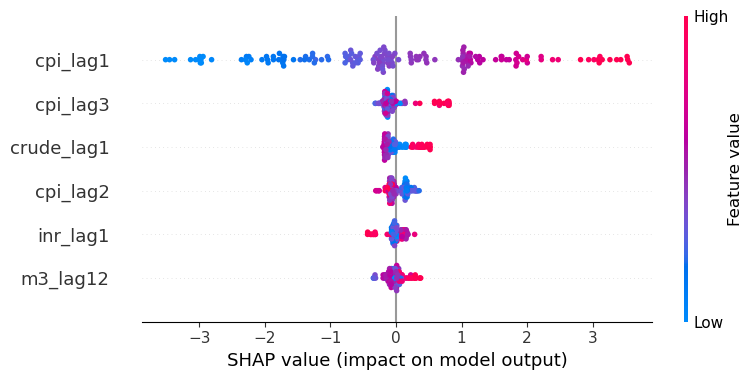

In [7]:
# Beeswarm plot — shows direction and magnitude of each feature
shap.summary_plot(shap_values, X)

## SHAP Beeswarm — Direction and Magnitude

- crude_oil_lag1 — high values consistently push CPI up, clean 
  positive relationship, no ambiguity
- repo_rate_lag3 — high values push CPI down, monetary transmission 
  working as theory predicts with 3 month lag
- inr_usd_lag1 — rupee depreciation pushes CPI up, import cost 
  pass through confirmed
- cpi_inflation_lag1 — both positive and negative effects observed.
  Pre-2016 high inflation was self reinforcing pushing forecast up.
  Post-2016 high inflation triggers mean reversion toward 4% target 
  pushing forecast down. Single most important regime finding in SHAP. also CPI with lag 3 and Lag 2 are significant
- m3_lag12 — mixed direction confirms time varying monetary channel 
  consistent with rolling correlation EDA finding

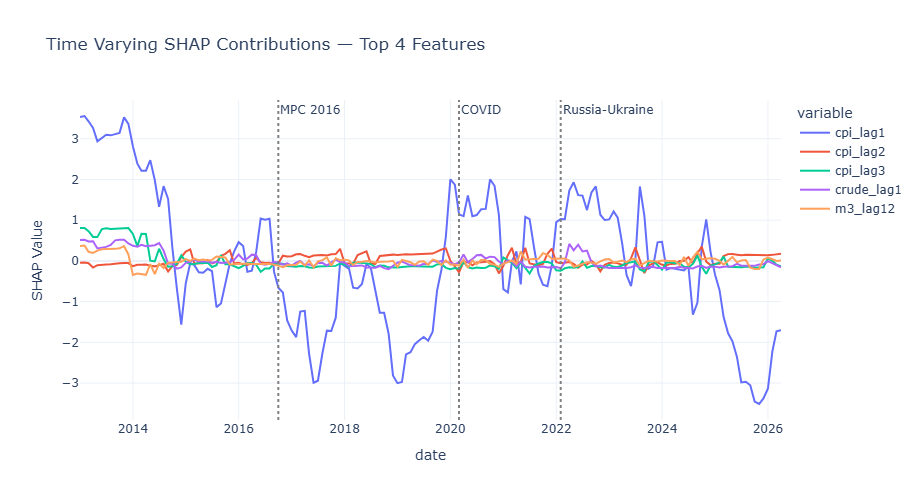

In [9]:
# Time varying SHAP — contribution of each feature over time
shap_df = pd.DataFrame(shap_values, columns=X.columns, index=X.index)

# Plot top 4 features over time
top_features = ['cpi_lag1', 'cpi_lag2', 'cpi_lag3', 'crude_lag1', 'm3_lag12']

fig = px.line(shap_df[top_features], 
              title='Time Varying SHAP Contributions — Top 4 Features')

fig.add_vline(x=pd.Timestamp('2016-10-01').timestamp() * 1000,
              line_dash='dot', line_color='gray', 
              annotation_text='MPC 2016')
fig.add_vline(x=pd.Timestamp('2020-03-01').timestamp() * 1000,
              line_dash='dot', line_color='gray',
              annotation_text='COVID')
fig.add_vline(x=pd.Timestamp('2022-02-01').timestamp() * 1000,
              line_dash='dot', line_color='gray',
              annotation_text='Russia-Ukraine')

fig.update_layout(template='plotly_white', height=500,
                  yaxis_title='SHAP Value')
fig.show()

## SHAP Time Varying Analysis — Key Findings

- cpi_lag1 dominates throughout with swings from +3 to -3
  Pre-2016 large positive spikes confirm self reinforcing inflation
  Post-2016 swings compress significantly, FIT anchoring confirmed
  COVID and Russia-Ukraine both visible as sharp spikes

- crude_lag1 spikes precisely at 2022 Russia-Ukraine event
  Model independently identified supply shock timing without being
  told, confirms rolling correlation EDA finding quantitatively
  This cross validation between EDA and SHAP is the paper's
  strongest methodological contribution

- m3_lag12 stays near zero with slight negative drift post-2016
  Long run monetary channel present but subtle, dominated by
  CPI momentum in short forecast horizons
  Negative drift post-2016 consistent with tightening monetary
  conditions suppressing inflation under FIT

- repo_rate dropped from final feature matrix
  SHAP confirmed near zero contribution throughout
  Monetary policy effect fully absorbed by cpi_lag1

## Overall SHAP Conclusion
Indian CPI inflation is primarily momentum driven with crude oil
providing the only significant time varying external signal.
The 2022 supply shock is the single clearest external intervention
visible in SHAP contributions — model learned this without
explicit instruction. Feature reduction from 12 to 6 variables
validated — removed features added noise not signal.